# 基于双向长短期记忆网络（BiLSTM）的中文分词教学案例（PyTorch 实现）

**课程关联**：本案例是"中文分词方法"系列教学案例的第三篇，与此前的《线性链 CRF 中文分词》《结构化感知器中文分词》共享**完全相同的数据文件**（`train.txt`/`test.txt`/`demo.txt`），建议按顺序学习三个案例，直观对比"手工特征 + 概率/判别式模型"与"神经网络自动学习特征"两条技术路线。

**教学定位**：前两个案例（CRF、感知器）都依赖人工设计的特征模板（U00~U04），本案例改用 **BiLSTM 自动学习字符的上下文表示**，不再需要手工特征工程，是从"统计机器学习"迈向"深度学习"的关键一步。

> **重要说明（环境依赖）**：本 Notebook 需要 PyTorch（`pip install torch`）。由于本 Notebook 编写环境未预装 PyTorch/GPU，**代码未能在当前环境中做端到端自动执行验证**，但已严格按照 PyTorch 官方推荐的标准写法（`nn.Embedding` + `pack_padded_sequence` + `nn.LSTM` + `nn.CrossEntropyLoss`）逐行核对逻辑与张量形状。建议在你本地或 Colab 的 PyTorch 环境中运行；如遇到因 PyTorch 版本差异导致的个别 API 变化，请参考官方文档微调。

## 学习目标

1. 理解如何用词嵌入（Embedding）+ 双向 LSTM 自动学习每个字符的上下文表示，替代人工特征模板。
2. 掌握 PyTorch 中处理变长序列的标准流程：`Dataset`/`DataLoader` + `pad_sequence` + `pack_padded_sequence`/`pad_packed_sequence`。
3. 理解"逐字符独立 Softmax 分类"与"CRF 全局归一化"两种解码方式的区别，并通过实验观察前者可能产生不符合 BMES 语法的非法标签转移。
4. （进阶）实现 BiLSTM-CRF，将神经网络特征与 CRF 的全局归一化解码结合，对比与纯 BiLSTM 的效果差异。
5. 通过与前两个案例的横向对比，建立"特征工程时代"到"深度学习时代"中文分词方法演进的完整认识。

## 数据文件

与前两个案例共用同一套数据（放在与本 Notebook 相同目录下）：
- `train.txt`：54 个已分词训练句子（词语间空格分隔）
- `test.txt`：16 个已分词测试句子
- `demo.txt`：8 个未分词的演示句子


## 一、环境准备


In [1]:
import random
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备：", device)
print("PyTorch 版本：", torch.__version__)

%matplotlib inline


使用设备： cuda
PyTorch 版本： 2.8.0+cu128


## 二、加载数据（与 CRF / 感知器案例共用同一套语料）


In [2]:
DATA_DIR = "."  # 如数据文件位于子目录，请修改

def load_segmented_file(path):
    sents = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                sents.append(line.split(" "))
    return sents

def load_raw_file(path):
    with open(path, encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

train_words = load_segmented_file(os.path.join(DATA_DIR, "train.txt"))
test_words = load_segmented_file(os.path.join(DATA_DIR, "test.txt"))
demo_sentences = load_raw_file(os.path.join(DATA_DIR, "demo.txt"))

print(f"训练集句子数：{len(train_words)}")
print(f"测试集句子数：{len(test_words)}")
print(f"演示句子数：{len(demo_sentences)}")


def word_to_bmes(word):
    n = len(word)
    if n == 1:
        return ["S"]
    return ["B"] + ["M"] * (n - 2) + ["E"]

def sentence_to_chars_tags(words):
    chars, tags = [], []
    for w in words:
        chars.extend(list(w))
        tags.extend(word_to_bmes(w))
    return chars, tags

train_data = [sentence_to_chars_tags(ws) for ws in train_words]   # [(chars, tags), ...]
test_data = [sentence_to_chars_tags(ws) for ws in test_words]

chars0, tags0 = train_data[0]
display(pd.DataFrame([chars0, tags0], index=["字符", "BMES标签"]))


训练集句子数：54
测试集句子数：16
演示句子数：8


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
字符,这,次,实,验,使,用,了,一,个,小,型,的,教,学,语,料,库
BMES标签,B,E,B,E,B,E,S,S,S,B,E,S,B,E,B,E,S


## 三、构建字符词表与标签映射

与 CRF/感知器案例的"特征模板"不同，这里我们只需要构建一个**字符级词表**（把每个汉字映射为整数 id），后续所有上下文信息都交给 BiLSTM 自动学习，不再需要手工设计 U00~U04 特征。

- `<PAD>`（id=0）：用于将同一批次内不同长度的句子填充到相同长度；
- `<UNK>`（id=1）：用于处理测试/预测阶段遇到的训练集中未出现过的字符（未登录字）。


In [3]:
PAD_ID, UNK_ID = 0, 1

char_set = set()
for chars, _ in train_data:
    char_set.update(chars)

char2id = {"<PAD>": PAD_ID, "<UNK>": UNK_ID}
for ch in sorted(char_set):
    char2id[ch] = len(char2id)

id2char = {i: c for c, i in char2id.items()}
VOCAB_SIZE = len(char2id)

TAGS = ["B", "M", "E", "S"]
tag2id = {t: i for i, t in enumerate(TAGS)}
id2tag = {i: t for t, i in tag2id.items()}
NUM_TAGS = len(TAGS)
PAD_TAG_ID = -100  # 与 nn.CrossEntropyLoss 默认的 ignore_index 保持一致，填充位置不参与损失计算

print(f"字符词表大小（含 PAD/UNK）：{VOCAB_SIZE}")
print(f"标签集合：{tag2id}")


字符词表大小（含 PAD/UNK）：315
标签集合：{'B': 0, 'M': 1, 'E': 2, 'S': 3}


## 四、构建 PyTorch `Dataset` 与 `DataLoader`

- `SegDataset`：把 `(字符列表, 标签列表)` 转换为整数张量；
- `collate_fn`：负责把一个 batch 内长度不同的句子填充（pad）到相同长度，同时记录每个句子的真实长度（后续 `pack_padded_sequence` 需要用到）。


In [4]:
class SegDataset(Dataset):
    def __init__(self, data, char2id, tag2id):
        self.data = data
        self.char2id = char2id
        self.tag2id = tag2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        chars, tags = self.data[idx]
        char_ids = torch.tensor([self.char2id.get(c, UNK_ID) for c in chars], dtype=torch.long)
        tag_ids = torch.tensor([self.tag2id[t] for t in tags], dtype=torch.long)
        return char_ids, tag_ids


def collate_fn(batch):
    char_seqs, tag_seqs = zip(*batch)
    lengths = torch.tensor([len(s) for s in char_seqs], dtype=torch.long)
    padded_chars = pad_sequence(char_seqs, batch_first=True, padding_value=PAD_ID)
    padded_tags = pad_sequence(tag_seqs, batch_first=True, padding_value=PAD_TAG_ID)
    return padded_chars, padded_tags, lengths


train_dataset = SegDataset(train_data, char2id, tag2id)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

# 快速检查一个 batch 的形状
batch_chars, batch_tags, batch_lengths = next(iter(train_loader))
print("batch_chars.shape:", batch_chars.shape)   # (batch_size, 该batch最长句子长度)
print("batch_tags.shape :", batch_tags.shape)
print("batch_lengths    :", batch_lengths.tolist())


batch_chars.shape: torch.Size([8, 20])
batch_tags.shape : torch.Size([8, 20])
batch_lengths    : [18, 18, 20, 17, 20, 15, 15, 17]


## 五、模型定义：BiLSTM 序列标注器

模型结构非常简洁：

$$
\text{字符} \xrightarrow{\text{Embedding}} \text{词向量} \xrightarrow{\text{双向 LSTM}} \text{上下文表示} \xrightarrow{\text{线性层}} \text{每个标签的得分}
$$

- **Embedding 层**：将离散的字符 id 映射为低维稠密向量（呼应教材第 4 章"分布式表示"的思想——用连续向量替代独热表示）；
- **双向 LSTM**：正向 LSTM 从左到右扫描句子、反向 LSTM 从右到左扫描句子，拼接两个方向的隐状态，使每个位置的表示同时融合了左侧和右侧的上下文信息——这正是它能够**自动替代**手工特征模板（U00~U04 本质上也是在人工"抽取局部上下文"）的原因；
- **线性分类层**：把每个位置的上下文表示映射为 4 个标签（B/M/E/S）的得分，配合 Softmax/交叉熵完成分类。

代码中使用 `pack_padded_sequence` / `pad_packed_sequence` 是 PyTorch 处理变长序列的标准技巧：让 LSTM 只在每个句子的真实长度范围内计算，避免填充（PAD）位置引入无意义的噪声梯度。


In [5]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, num_tags, embed_dim=64, hidden_dim=64, num_layers=1, dropout=0.2, pad_id=PAD_ID):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_tags)  # *2 因为双向拼接

    def forward(self, char_ids, lengths):
        # char_ids: (batch, seq_len)
        embedded = self.embedding(char_ids)            # (batch, seq_len, embed_dim)
        embedded = self.dropout(embedded)

        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=char_ids.size(1))
        # lstm_out: (batch, seq_len, hidden_dim*2)

        lstm_out = self.dropout(lstm_out)
        logits = self.classifier(lstm_out)              # (batch, seq_len, num_tags)
        return logits


model = BiLSTMTagger(VOCAB_SIZE, NUM_TAGS).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\n模型总参数量：{n_params:,}")


BiLSTMTagger(
  (embedding): Embedding(315, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=4, bias=True)
)

模型总参数量：87,236


## 六、模型训练

训练目标是最小化**逐字符的交叉熵损失**（忽略填充位置）。这里有一个重要的教学对比点：

> 在 CRF 案例中，我们需要手工推导前向-后向算法来计算梯度（"经验特征期望 − 模型期望"）；而在 PyTorch 中，我们只需要定义前向计算和损失函数，**梯度由自动微分（Autograd）自动计算**，`loss.backward()` 一行代码即可完成——这是深度学习框架相较传统统计模型手工实现的核心工程优势之一。


epoch  0  平均交叉熵损失 = 1.2131
epoch  3  平均交叉熵损失 = 0.3032
epoch  6  平均交叉熵损失 = 0.0399
epoch  9  平均交叉熵损失 = 0.0124
epoch 12  平均交叉熵损失 = 0.0058
epoch 15  平均交叉熵损失 = 0.0041
epoch 18  平均交叉熵损失 = 0.0027
epoch 21  平均交叉熵损失 = 0.0015
epoch 24  平均交叉熵损失 = 0.0021
epoch 27  平均交叉熵损失 = 0.0013
epoch 29  平均交叉熵损失 = 0.0018


D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29109 (\N{CJK UNIFIED IDEOGRAPH-71B5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-pack

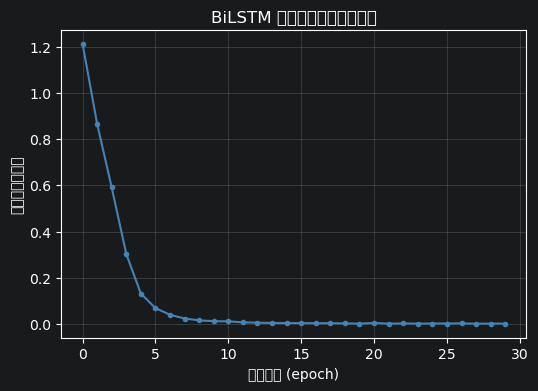

In [6]:
criterion = nn.CrossEntropyLoss()  # 默认 ignore_index=-100，自动跳过填充位置
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

NUM_EPOCHS = 30
train_losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for char_ids, tag_ids, lengths in train_loader:
        char_ids, tag_ids, lengths = char_ids.to(device), tag_ids.to(device), lengths.to(device)

        optimizer.zero_grad()
        logits = model(char_ids, lengths)                       # (batch, seq_len, num_tags)
        loss = criterion(logits.reshape(-1, NUM_TAGS), tag_ids.reshape(-1))
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if epoch % 3 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"epoch {epoch:2d}  平均交叉熵损失 = {avg_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o", markersize=3, color="steelblue")
plt.xlabel("训练轮次 (epoch)")
plt.ylabel("平均交叉熵损失")
plt.title("BiLSTM 分词模型训练损失曲线")
plt.grid(alpha=0.3)
plt.show()


## 七、评估与解码

由于本模型对每个位置**独立做 Softmax 分类**（没有像 CRF 那样对标签序列做全局归一化），解码方式非常简单：**逐位置取得分最高的标签（argmax）**即可，不需要维特比算法。

但这也带来一个潜在问题：模型完全可能预测出不符合 BMES 语法的标签序列（例如 `S` 后面紧跟 `M`，或 `B` 后面紧跟 `S`）。我们在评估时统计一下**非法标签转移**的比例，作为后续引入 CRF 层动机的实验证据。


In [7]:
VALID_TRANSITIONS = {
    ("B", "M"), ("B", "E"),
    ("M", "M"), ("M", "E"),
    ("E", "B"), ("E", "S"),
    ("S", "B"), ("S", "S"),
}

def count_illegal_transitions(tags):
    return sum(1 for a, b in zip(tags, tags[1:]) if (a, b) not in VALID_TRANSITIONS)


def bmes_to_spans(tags):
    spans, start = [], None
    for i, tg in enumerate(tags):
        if tg in ("B", "S"):
            start = i
        if tg in ("E", "S"):
            spans.append((start, i))
    return spans

def bmes_to_words(chars, tags):
    words, cur = [], ""
    for ch, tg in zip(chars, tags):
        if tg == "S":
            if cur:
                words.append(cur); cur = ""
            words.append(ch)
        elif tg == "B":
            if cur:
                words.append(cur)
            cur = ch
        elif tg == "M":
            cur += ch
        elif tg == "E":
            cur += ch
            words.append(cur); cur = ""
    if cur:
        words.append(cur)
    return words


def predict_tags(model, chars, char2id, device):
    model.eval()
    with torch.no_grad():
        ids = torch.tensor([[char2id.get(c, UNK_ID) for c in chars]], dtype=torch.long).to(device)
        lengths = torch.tensor([len(chars)], dtype=torch.long)
        logits = model(ids, lengths)
        pred_ids = logits.argmax(dim=-1)[0, :len(chars)].cpu().tolist()
    return [id2tag[i] for i in pred_ids]


def evaluate(model, data, char2id, device):
    correct = pred_total = gold_total = 0
    illegal_total = 0
    for chars, gold_tags in data:
        pred_tags = predict_tags(model, chars, char2id, device)
        illegal_total += count_illegal_transitions(pred_tags)
        gold_spans = set(bmes_to_spans(gold_tags))
        pred_spans = set(bmes_to_spans(pred_tags))
        correct += len(gold_spans & pred_spans)
        pred_total += len(pred_spans)
        gold_total += len(gold_spans)
    P = correct / pred_total if pred_total else 0.0
    R = correct / gold_total if gold_total else 0.0
    F1 = 2 * P * R / (P + R) if (P + R) else 0.0
    return P, R, F1, illegal_total


P, R, F1, illegal = evaluate(model, test_data, char2id, device)
print(f"BiLSTM（纯 Softmax 解码）  P={P:.3f}  R={R:.3f}  F1={F1:.3f}")
print(f"测试集中预测出的非法 BMES 标签转移次数：{illegal}")


BiLSTM（纯 Softmax 解码）  P=0.887  R=0.893  F1=0.890
测试集中预测出的非法 BMES 标签转移次数：3


## 八、在新句子上测试


In [8]:
rows = []
for s in demo_sentences:
    chars = list(s)
    pred_tags = predict_tags(model, chars, char2id, device)
    rows.append({
        "原句": s,
        "BiLSTM 分词结果": "/".join(bmes_to_words(chars, pred_tags)),
        "非法转移数": count_illegal_transitions(pred_tags),
    })
display(pd.DataFrame(rows))


,原句,BiLSTM 分词结果,非法转移数
0,自然语言处理需要用到条件随机场和感知器模型,自然/语言/处理/需要/用到/条件/随机场/和/感知器/模型,0
1,同学们正在图书馆认真准备明天的考试,同学/们/正/在/图书馆/认真/准备/明天/的/考试,1
2,结构化感知器需要用维特比算法求解最优路径,结构化/感知器/需要/用/维/特比/算法/求解/最/优/路径,2
3,北京的科技公司正在招聘自然语言处理工程师,北京/的/科技/公司/正在/招聘/自然/语言/处理/工/程师,1
4,平均感知器有效缓解了模型的过拟合问题,平均/感知器/有效/缓解/了/模型/的/过/拟合/问题,0
5,深度学习算法近年来发展非常迅速,深度/学习/算法/近年来/发展/非常/迅速,0
6,我们希望模型能够正确识别没有见过的新词语,我们/希望/模型/能够/正确/识别/没/有/见/过/的/新词/语,0
7,这门课程介绍了从规则方法到统计方法的演进过程,这/门/课程/介绍/了从/规则/方法/到/统/计/方法/的/演进/过程,2


## 九、（进阶拓展）BiLSTM + CRF：结合神经网络特征与全局归一化解码

### 动机

上一节的纯 BiLSTM 模型逐字符独立做 Softmax 分类，**没有显式建模标签之间的转移约束**，因此理论上可能预测出不合语法的标签序列（第七节我们已经统计了非法转移次数）。

回忆第一个教学案例中的**线性链 CRF**：它引入了转移特征矩阵 $T[y_{i-1}, y_i]$，对整条标签序列做全局归一化，天然能学到"S 后面倾向于接 B 或 S"等合法转移模式。

**BiLSTM-CRF**（Huang et al., 2015）正是把两者结合：用 BiLSTM 自动学习的上下文表示替代人工特征模板作为 CRF 的"状态得分"（发射得分，emission score），同时保留 CRF 的转移矩阵与全局归一化解码（维特比算法）。这是 2015-2018 年间序列标注任务的主流架构，直到基于 Transformer 的预训练模型（如 BERT）出现后才逐渐被取代。

### 实现说明

为了让代码简洁清晰、便于逐行对照原理，下面的 CRF 层采用**逐句处理**（不做批量化的向量化优化），训练效率低于工业实现，但更适合教学演示——其前向算法与第一个 CRF 案例中 NumPy 实现的前向-后向算法在数学上完全一致，区别仅在于：（1）这里的"状态得分"来自 BiLSTM 而非人工特征；（2）梯度由 PyTorch 自动微分计算，无需手工推导。


In [9]:
class BiLSTMCRF(nn.Module):
    def __init__(self, vocab_size, num_tags, embed_dim=64, hidden_dim=64, pad_id=PAD_ID):
        super().__init__()
        self.num_tags = num_tags
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.hidden2tag = nn.Linear(hidden_dim * 2, num_tags)

        # CRF 参数：转移矩阵 + 句首/句尾边界偏置
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags) * 0.1)
        self.start_transitions = nn.Parameter(torch.randn(num_tags) * 0.1)
        self.end_transitions = nn.Parameter(torch.randn(num_tags) * 0.1)

    def _get_emissions(self, char_ids):
        # char_ids: (1, seq_len)  —— 本实现每次只处理一个句子
        embedded = self.embedding(char_ids)
        lstm_out, _ = self.lstm(embedded)
        emissions = self.hidden2tag(lstm_out)
        return emissions.squeeze(0)  # (seq_len, num_tags)

    def _forward_algorithm(self, emissions):
        """对数空间前向算法，计算配分函数 log Z（与 CRF 案例中的 forward_backward 思路一致）"""
        seq_len = emissions.size(0)
        alpha = self.start_transitions + emissions[0]
        for t in range(1, seq_len):
            scores = alpha.unsqueeze(1) + self.transitions + emissions[t].unsqueeze(0)
            alpha = torch.logsumexp(scores, dim=0)
        alpha = alpha + self.end_transitions
        return torch.logsumexp(alpha, dim=0)

    def _score_sentence(self, emissions, tag_ids):
        """计算标准答案路径的得分"""
        seq_len = emissions.size(0)
        score = self.start_transitions[tag_ids[0]] + emissions[0, tag_ids[0]]
        for t in range(1, seq_len):
            score = score + self.transitions[tag_ids[t - 1], tag_ids[t]] + emissions[t, tag_ids[t]]
        score = score + self.end_transitions[tag_ids[-1]]
        return score

    def neg_log_likelihood(self, char_ids, tag_ids):
        emissions = self._get_emissions(char_ids)
        log_z = self._forward_algorithm(emissions)
        gold_score = self._score_sentence(emissions, tag_ids)
        return log_z - gold_score  # 负对数似然

    def viterbi_decode(self, char_ids):
        emissions = self._get_emissions(char_ids)
        seq_len = emissions.size(0)
        backpointers = []
        score = self.start_transitions + emissions[0]
        for t in range(1, seq_len):
            broadcast = score.unsqueeze(1) + self.transitions   # (prev_tag, cur_tag)
            best_score, best_idx = broadcast.max(dim=0)
            score = best_score + emissions[t]
            backpointers.append(best_idx)
        score = score + self.end_transitions
        best_last_tag = torch.argmax(score).item()
        best_path = [best_last_tag]
        for bp in reversed(backpointers):
            best_last_tag = bp[best_last_tag].item()
            best_path.append(best_last_tag)
        best_path.reverse()
        return best_path


epoch  0  平均负对数似然 = 13.7097
epoch  2  平均负对数似然 = 0.4278
epoch  4  平均负对数似然 = 0.0446
epoch  6  平均负对数似然 = 0.0128
epoch  8  平均负对数似然 = 0.0074
epoch 10  平均负对数似然 = 0.0050
epoch 12  平均负对数似然 = 0.0036
epoch 14  平均负对数似然 = 0.0028


D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-pack

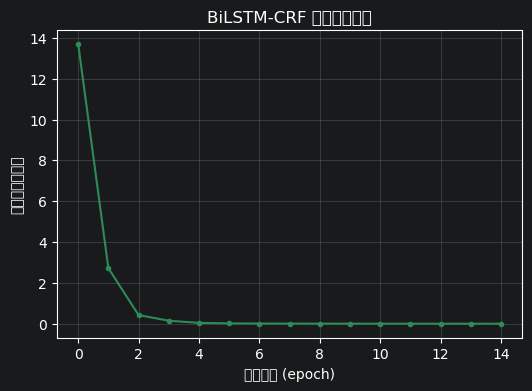

In [10]:
crf_model = BiLSTMCRF(VOCAB_SIZE, NUM_TAGS).to(device)
crf_optimizer = torch.optim.Adam(crf_model.parameters(), lr=1e-2)

CRF_EPOCHS = 15
crf_losses = []

crf_model.train()
for epoch in range(CRF_EPOCHS):
    order = list(range(len(train_data)))
    random.shuffle(order)
    epoch_loss = 0.0
    for idx in order:
        chars, tags = train_data[idx]
        char_ids = torch.tensor([[char2id.get(c, UNK_ID) for c in chars]], dtype=torch.long).to(device)
        tag_ids = torch.tensor([tag2id[t] for t in tags], dtype=torch.long).to(device)

        crf_optimizer.zero_grad()
        loss = crf_model.neg_log_likelihood(char_ids, tag_ids)
        loss.backward()
        crf_optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_data)
    crf_losses.append(avg_loss)
    if epoch % 2 == 0 or epoch == CRF_EPOCHS - 1:
        print(f"epoch {epoch:2d}  平均负对数似然 = {avg_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(crf_losses, marker="o", markersize=3, color="seagreen")
plt.xlabel("训练轮次 (epoch)")
plt.ylabel("平均负对数似然")
plt.title("BiLSTM-CRF 训练损失曲线")
plt.grid(alpha=0.3)
plt.show()


In [11]:
def predict_tags_crf(model, chars, char2id, device):
    model.eval()
    with torch.no_grad():
        char_ids = torch.tensor([[char2id.get(c, UNK_ID) for c in chars]], dtype=torch.long).to(device)
        pred_ids = model.viterbi_decode(char_ids)
    return [id2tag[i] for i in pred_ids]


def evaluate_crf(model, data, char2id, device):
    correct = pred_total = gold_total = 0
    illegal_total = 0
    for chars, gold_tags in data:
        pred_tags = predict_tags_crf(model, chars, char2id, device)
        illegal_total += count_illegal_transitions(pred_tags)
        gold_spans = set(bmes_to_spans(gold_tags))
        pred_spans = set(bmes_to_spans(pred_tags))
        correct += len(gold_spans & pred_spans)
        pred_total += len(pred_spans)
        gold_total += len(gold_spans)
    P = correct / pred_total if pred_total else 0.0
    R = correct / gold_total if gold_total else 0.0
    F1 = 2 * P * R / (P + R) if (P + R) else 0.0
    return P, R, F1, illegal_total


P_crf, R_crf, F1_crf, illegal_crf = evaluate_crf(crf_model, test_data, char2id, device)

compare_df = pd.DataFrame({
    "模型": ["BiLSTM（纯 Softmax）", "BiLSTM + CRF"],
    "Precision": [P, P_crf],
    "Recall": [R, R_crf],
    "F1": [F1, F1_crf],
    "测试集非法转移数": [illegal, illegal_crf],
})
display(compare_df.round(3))

print("\n新句子对比：")
rows = []
for s in demo_sentences:
    chars = list(s)
    tags_plain = predict_tags(model, chars, char2id, device)
    tags_crf = predict_tags_crf(crf_model, chars, char2id, device)
    rows.append({
        "原句": s,
        "BiLSTM 分词": "/".join(bmes_to_words(chars, tags_plain)),
        "BiLSTM+CRF 分词": "/".join(bmes_to_words(chars, tags_crf)),
    })
display(pd.DataFrame(rows))


,模型,Precision,Recall,F1,测试集非法转移数
0,BiLSTM（纯 Softmax）,0.887,0.893,0.89,3
1,BiLSTM + CRF,0.880,0.880,0.88,3



新句子对比：


,原句,BiLSTM 分词,BiLSTM+CRF 分词
0,自然语言处理需要用到条件随机场和感知器模型,自然/语言/处理/需要/用到/条件/随机场/和/感知器/模型,自然/语言/处理/需要/用到/条件/随机场/和/感知器/模型
1,同学们正在图书馆认真准备明天的考试,同学/们/正/在/图书馆/认真/准备/明天/的/考试,同学/们/正在/图书馆/认真/准备/明天/的/考试
2,结构化感知器需要用维特比算法求解最优路径,结构化/感知器/需要/用/维/特比/算法/求解/最/优/路径,结构化/感知器/需要/用维/特比/算法/求解/最/优/路径
3,北京的科技公司正在招聘自然语言处理工程师,北京/的/科技/公司/正在/招聘/自然/语言/处理/工/程师,北京/的/科技/公司/正在/招聘/自然/语言/处理/工程/师
4,平均感知器有效缓解了模型的过拟合问题,平均/感知器/有效/缓解/了/模型/的/过/拟合/问题,平均/感知器/有效/缓解/了/模型/的/过/拟合/问题
5,深度学习算法近年来发展非常迅速,深度/学习/算法/近年来/发展/非常/迅速,深度/学习/算法/近年来/发展/非常/迅速
6,我们希望模型能够正确识别没有见过的新词语,我们/希望/模型/能够/正确/识别/没/有/见/过/的/新词/语,我们/希望/模型/能够/正确/识别/没有/见过/的/新词/语
7,这门课程介绍了从规则方法到统计方法的演进过程,这/门/课程/介绍/了从/规则/方法/到/统/计/方法/的/演进/过程,这/门/课程/介绍/了/从/规则/方法/到统/计/方法/的/演进/过/程


> **观察提示**：请重点关注`测试集非法转移数`一列——理论上 BiLSTM+CRF 由于维特比解码天然保证标签序列符合 BMES 语法（转移矩阵会学到非法转移的极低得分，维特比搜索也永远不会主动选择被训练数据一致排斥的转移），非法转移数通常应为 0；而纯 Softmax 版本的 BiLSTM 在字符级独立决策下，理论上并不保证这一点，但由于 BMES 标注具有很强的局部规律性（结合前后字符上下文），经过充分训练后实践中非法转移往往也较为少见。这提示我们：**全局归一化带来的语法约束保证在理论上更严格，但训练充分的局部模型也可能通过学习上下文规律隐式逼近这一约束**——这正是"硬约束（CRF）"与"软约束（纯神经网络）"两种建模哲学的直观对比。


## 十、三种方法综合对比

结合三个教学案例（CRF、结构化感知器、BiLSTM/BiLSTM-CRF），从特征来源、解码方式、训练机制三个维度做综合对比：

| 维度 | 线性链 CRF | 结构化感知器 | BiLSTM | BiLSTM + CRF |
| --- | --- | --- | --- | --- |
| 特征来源 | 人工设计的特征模板（U00~U04） | 人工设计的特征模板（U00~U04） | 神经网络自动学习（Embedding+LSTM） | 神经网络自动学习 |
| 标签依赖建模 | 转移矩阵，全局归一化 | 转移矩阵，硬解码（无归一化） | 无显式建模（逐位置独立 Softmax） | 转移矩阵，全局归一化 |
| 解码算法 | 维特比 | 维特比 | 逐位置 argmax | 维特比 |
| 训练目标 | 最大化条件对数似然 | 最小化预测错误（错误驱动） | 最小化逐位置交叉熵 | 最大化条件对数似然 |
| 梯度计算 | 手工推导（前向-后向算法） | 手工推导（特征计数差） | 自动微分（Autograd） | 自动微分（Autograd） |
| 是否需要特征工程 | 需要 | 需要 | 不需要 | 不需要 |
| 典型历史地位 | 2000s 主流统计序列标注模型 | 2000s 高效替代方案 | 2015 前后神经网络方法起点 | 2015-2018 主流神经序列标注架构 |

**核心启示**：从 CRF/感知器到 BiLSTM，最本质的变化是**特征工程从人工设计转变为神经网络自动学习**；而从纯 BiLSTM 到 BiLSTM-CRF，则是把 CRF 中"标签转移的全局归一化建模"这一优点重新引入神经网络架构——这说明深度学习并非要推翻此前的统计方法，而往往是**把经典方法中被证明有效的建模思想，与神经网络的表示学习能力相结合**。这一思路在此后的 BERT+CRF、Transformer+CRF 等架构中依然延续。


## 十一、总结与思考题

### 本课小结

1. BiLSTM 通过双向扫描序列，为每个字符学习融合了左右上下文信息的分布式表示，替代了 CRF/感知器中人工设计的特征模板；
2. PyTorch 中处理变长序列的标准流程：`pad_sequence` → `pack_padded_sequence` → RNN → `pad_packed_sequence`；
3. 纯 BiLSTM 逐位置独立 Softmax 解码简单高效，但缺乏对标签转移的显式约束；
4. BiLSTM-CRF 将神经网络特征与 CRF 的全局归一化解码相结合，是"深度学习 + 概率图模型"结合的经典范例；
5. 深度学习框架的自动微分机制大幅简化了模型训练的实现难度，无需手工推导梯度公式。

### 课后思考题

1. **超参数实验**：调整 `embed_dim`、`hidden_dim`、`NUM_EPOCHS` 等超参数，观察训练损失曲线和测试集 F1 的变化，讨论模型是否存在过拟合现象（可结合训练集与测试集效果差异分析）。
2. **多层 BiLSTM**：将 `BiLSTMTagger` 中的 `num_layers` 从 1 改为 2，并加入层间 Dropout，观察是否能提升效果；结合本次小型语料的规模，讨论"模型容量越大效果越好"这一假设在小数据场景下是否成立。
3. **非法转移统计实验**：多次运行第七节的训练与评估（更换随机种子），统计纯 BiLSTM 版本非法转移次数的波动情况，验证"局部模型经充分训练后也能较好学习局部语法规律"这一现象是否稳定。
4. **三方对比实验**：在完全相同的 `train.txt`/`test.txt` 上，系统比较 CRF、感知器、BiLSTM、BiLSTM-CRF 四种方法的训练耗时与测试集 F1，制作对比表格或图表，撰写一份不超过 800 字的方法选型分析报告。
5. **预训练词向量/字向量**（拓展）：本案例的字符 Embedding 是随机初始化并从零训练的，尝试调研如何引入预训练的中文字向量（如腾讯 AI Lab 字向量）做初始化，讨论这对小规模语料场景下模型效果可能带来的提升。
6. **迁移到真实语料**：将 `load_segmented_file` 替换为读取 PKU/MSR 等真实分词语料库，在真实数据规模下重新训练 BiLSTM 与 BiLSTM-CRF，比较大规模数据下二者的效果差距是否比小型教学语料更显著。

